In [1]:
import pandas as pd
from sklearn.utils import shuffle

In [2]:
df = pd.read_csv("pulsar_data_train.csv")

In [3]:
df['target_class'].value_counts()

0.0    11375
1.0     1153
Name: target_class, dtype: int64

In [4]:
class_0 = df[df['target_class'] == 0]
class_1 = df[df['target_class'] == 1]

In [5]:
class_0_sample = class_0.sample(n=1100, random_state=42)
class_1_sample = class_1.sample(n=1100, random_state=42)

In [6]:
balanced_df = pd.concat([class_0_sample, class_1_sample])

In [7]:
balanced_df = shuffle(balanced_df, random_state=42).reset_index(drop=True)

In [8]:
balanced_df['target_class'].value_counts()

1.0    1100
0.0    1100
Name: target_class, dtype: int64

In [9]:
balanced_df.shape

(2200, 9)

In [10]:
balanced_df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [11]:
balanced_df.info()
balanced_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                2200 non-null   float64
 1    Standard deviation of the integrated profile  2200 non-null   float64
 2    Excess kurtosis of the integrated profile     1908 non-null   float64
 3    Skewness of the integrated profile            2200 non-null   float64
 4    Mean of the DM-SNR curve                      2200 non-null   float64
 5    Standard deviation of the DM-SNR curve        1996 non-null   float64
 6    Excess kurtosis of the DM-SNR curve           2200 non-null   float64
 7    Skewness of the DM-SNR curve                  2083 non-null   float64
 8   target_class                                   2200 non-null   float64
dtypes: float64(9)
memory usage: 154.8 KB


 Mean of the integrated profile                    0
 Standard deviation of the integrated profile      0
 Excess kurtosis of the integrated profile       292
 Skewness of the integrated profile                0
 Mean of the DM-SNR curve                          0
 Standard deviation of the DM-SNR curve          204
 Excess kurtosis of the DM-SNR curve               0
 Skewness of the DM-SNR curve                    117
target_class                                       0
dtype: int64

In [12]:
balanced_df.fillna(balanced_df.mean(), inplace=True)
balanced_df.isnull().sum()

 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

In [13]:
balanced_df['target_class'].value_counts()

1.0    1100
0.0    1100
Name: target_class, dtype: int64

In [14]:
balanced_df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,86.366456,42.985199,1.656276,7.959180,29.843844,40.223953,5.763375,64.466301,0.500000
std,38.564533,8.212711,1.846643,12.564402,42.120733,23.748802,4.797153,90.819395,0.500114
min,5.812500,24.772042,-1.118709,-1.334542,0.282609,7.565681,-2.282560,-1.931996,0.000000
25%,54.308594,36.687621,0.235810,0.093709,2.506480,17.803817,1.592888,1.877400,0.000000
50%,95.492188,43.471060,1.097028,1.295904,6.852007,40.017982,5.196643,34.693522,0.500000
75%,117.089844,49.152527,2.407940,11.206401,40.730978,60.537107,9.085017,91.764292,1.000000
max,167.593750,79.084407,8.069522,68.101622,200.500000,109.655345,32.198584,1072.957979,1.000000


In [15]:
balanced_df.groupby('target_class').mean()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve
target_class,,,,,,,,
0.0,116.141847,47.224517,0.393494,0.386872,9.640332,25.031917,8.748657,108.389610
1.0,56.591065,38.745882,2.919059,15.531489,50.047356,55.415990,2.778094,20.542991


In [16]:
import numpy as np

np.isinf(balanced_df).sum()

 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

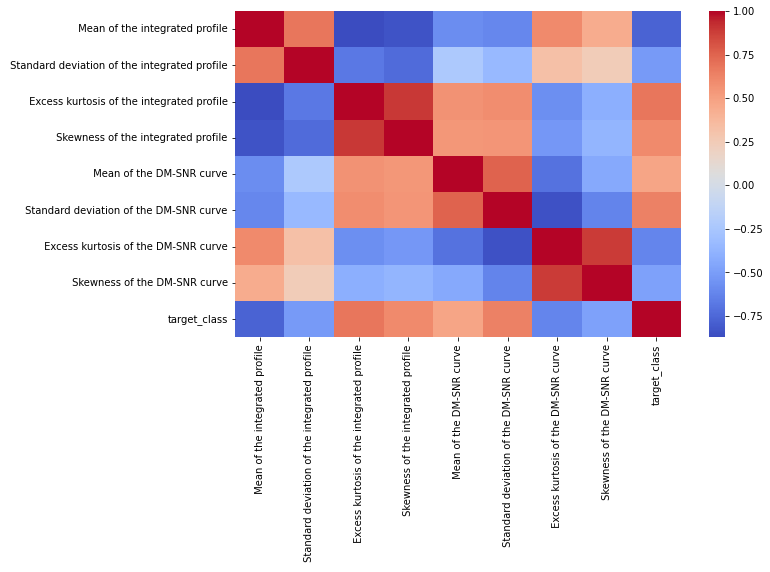

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(balanced_df.corr(), cmap='coolwarm')
plt.show()

The heatmap visually represents the relationships between all features in the dataset. It shows that features within the same signal group are strongly related, while features from different groups have weaker relationships. The target variable does not strongly depend on any single feature, indicating that classification depends on a combination of features. Overall, the heatmap confirms that the dataset contains meaningful patterns and is suitable for machine learning modeling.

In [18]:
X = balanced_df.drop('target_class', axis=1)
y = balanced_df['target_class']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression 
log_model = LogisticRegression(max_iter=1000) 
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90       220
         1.0       0.94      0.85      0.89       220

    accuracy                           0.90       440
   macro avg       0.90      0.90      0.90       440
weighted avg       0.90      0.90      0.90       440



In [23]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[209,  11],
       [ 33, 187]], dtype=int64)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9